In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pcn
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from hpc import utils
from pcn.models import PCModel
from pcn import plotting
from sklearn.model_selection import train_test_split
import torch.nn as nn
from hpc.layers import SparseLayer
from pcn.plotting import plot_levels

## Data

In [2]:
n_ec = 300
p = n_ec/(1.1*10**5)
n_dg = round(1.2*10**6*p)
n_ca3 = round(2.5*10**5*p)
n_ca1 = round(3.9*10**5*p)

In [3]:
act_fn1 = "relu"
_act_fn1 = torch.relu
EC_DG = SparseLayer(
    in_size=n_ec, 
    out_size=n_dg, 
    act_fn=_act_fn1,
    c=1,
    f=0.01,
    device=torch.device('cpu')
)
# torch.save(EC_DG.state_dict(), f'models/EC_DG_{act_fn1}_sparse.pt')
EC_DG.load_state_dict(torch.load(f'models/EC_DG_{act_fn1}_sparse.pt', weights_only=True))


act_fn2 = "heaviside"
_act_fn2 = torch.heaviside
DG_CA3 = SparseLayer(
    in_size=n_dg,
    out_size=n_ca3, 
    act_fn=_act_fn2,
    c=1,
    f=0.06,
    device=torch.device('cpu')
)
# torch.save(DG_CA3.state_dict(), f'models/DG_CA3_{act_fn2}_sparse.pt')
DG_CA3.load_state_dict(torch.load(f'models/DG_CA3_{act_fn2}_sparse.pt', weights_only=True))

<All keys matched successfully>

In [4]:
dataset_name = 'mnist'
size = (1, 28, 28)
N_patterns = int(0.1*n_ca3)

In [5]:
train_dataset = torch.load(f'./data/{dataset_name}_train.pt')
img_train = train_dataset['img']
ec_train = train_dataset['ec']
labels_train = train_dataset['labels']

with torch.no_grad():
    dg_train = EC_DG(ec_train)
    ca3_train = DG_CA3(dg_train)

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_43020\654522711.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'./data/{dataset_name}_train.p

In [6]:
valid_dataset = torch.load(f'./data/{dataset_name}_valid.pt')
img_valid =valid_dataset['img']
ec_valid = valid_dataset['ec']
labels_valid = valid_dataset['labels']

with torch.no_grad():
    dg_valid = EC_DG(ec_valid)
    ca3_valid = DG_CA3(dg_valid)

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_43020\2444734703.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  valid_dataset = torch.load(f'./data/{dataset_name}_valid.

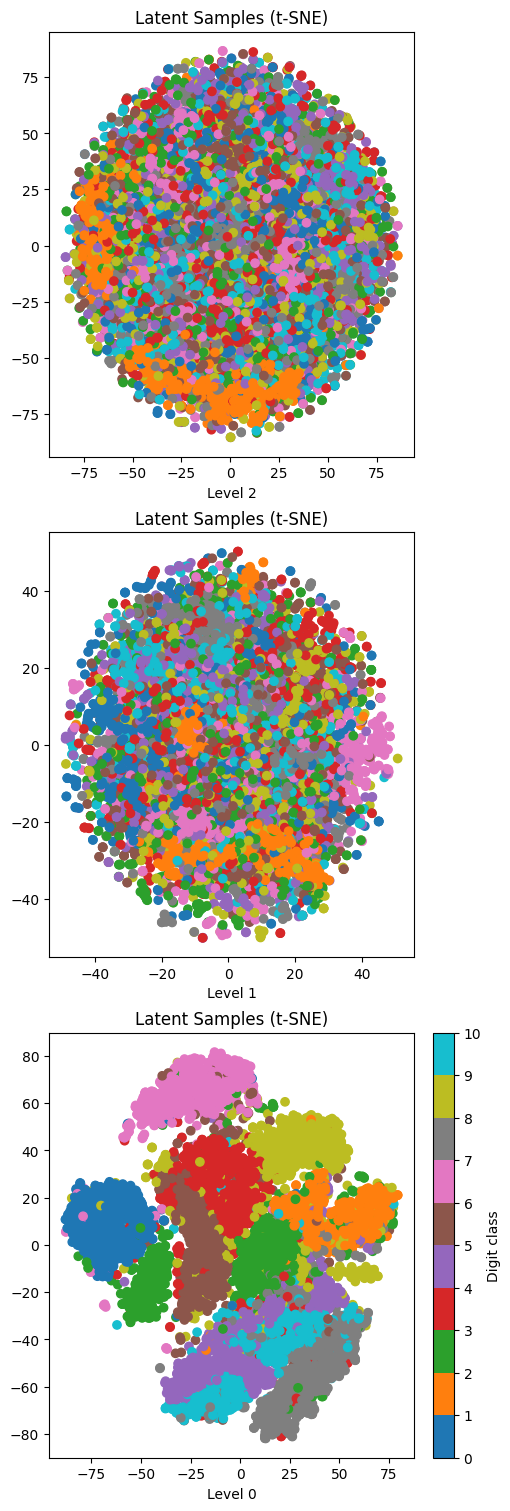

In [7]:
activities = [ec_valid, dg_valid, ca3_valid]
fig, axes = plot_levels(activities, labels_valid, tsne=True)

n_classes = len(labels_valid.unique())
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
cmap = (mpl.colors.ListedColormap(colors))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(0, n_classes))
plt.colorbar(sm, ax=axes[-1], ticks=np.linspace(0, n_classes, n_classes+1), label="Digit class")

## Training

In [17]:
batch_size = 64
seed = 0

pcn.utils.seed(seed)
g = torch.Generator()
g.manual_seed(seed)

train_tensordataset = TensorDataset(ca3_train, ec_train)
train_loader = DataLoader(
    train_tensordataset, 
    batch_size, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

valid_tensordataset = TensorDataset(ca3_valid, ec_valid)
valid_loader = DataLoader(
    valid_tensordataset, 
    batch_size, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

small_train_tensordataset = TensorDataset(ca3_train[-batch_size:], ec_train[-batch_size:])
small_train_loader = DataLoader(
    small_train_tensordataset, 
    batch_size, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

In [8]:
# dataset params
train_size = None
test_size = None
normalize = True
batch_size = 64

# inference params
mu_dt = 0.01
n_test_iters = 200
n_max_iters = 20000
step_tolerance = 1e-5
init_std = 0.01
fixed_preds_test = False

# model params
use_bias = True
kaiming_init = False
n_ec = 300
act_fn = "tanh"
kaiming = False

In [9]:
if dataset_name == 'mnist':
    n_vc = 550
elif dataset_name  == 'fmnist':
    n_vc = 750
else:
    n_vc = 2000

nodes = [n_ec, n_vc, np.prod(size)]
    
model_name = f"pcn-{dataset_name}-n_vc={n_vc}-n_ec={n_ec}" 
pcmodel = PCModel(
    nodes=nodes, mu_dt=mu_dt, act_fn=act_fn, use_bias=use_bias, kaiming_init=kaiming_init
)
pcmodel.load_state_dict(torch.load(f"../unsupervised-pcn/models/{model_name}.pt", map_location=pcn.utils.DEVICE, weights_only=True))

<All keys matched successfully>

### Small training set

#### Overfitting

In [20]:
device = pcn.utils.DEVICE

model = nn.Sequential(
    nn.Linear(in_features=n_ca3, out_features=n_ca1),
    nn.Tanh(), 
    nn.Linear(in_features=n_ca1, out_features=n_ec),
    nn.Tanh()
).to(device)

criterion = nn.MSELoss()
lr = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [21]:
errors_train, errors_valid = utils.train_model(model, small_train_loader, valid_loader, optimizer, criterion, device, lambda_reg=0)

Epoch [  5/ 50] finished. Training loss: 0.00635. Validation loss: 0.00806.
Epoch [ 10/ 50] finished. Training loss: 0.00418. Validation loss: 0.00776.
Epoch [ 15/ 50] finished. Training loss: 0.00268. Validation loss: 0.00764.
Epoch [ 20/ 50] finished. Training loss: 0.00163. Validation loss: 0.00758.
Epoch [ 25/ 50] finished. Training loss: 0.00095. Validation loss: 0.00756.
Epoch [ 30/ 50] finished. Training loss: 0.00052. Validation loss: 0.00756.
Epoch [ 35/ 50] finished. Training loss: 0.00027. Validation loss: 0.00758.
Epoch [ 40/ 50] finished. Training loss: 0.00013. Validation loss: 0.00760.
Epoch [ 45/ 50] finished. Training loss: 0.00006. Validation loss: 0.00762.
Epoch [ 50/ 50] finished. Training loss: 0.00003. Validation loss: 0.00764.


Text(0, 0.5, 'MSE Loss')

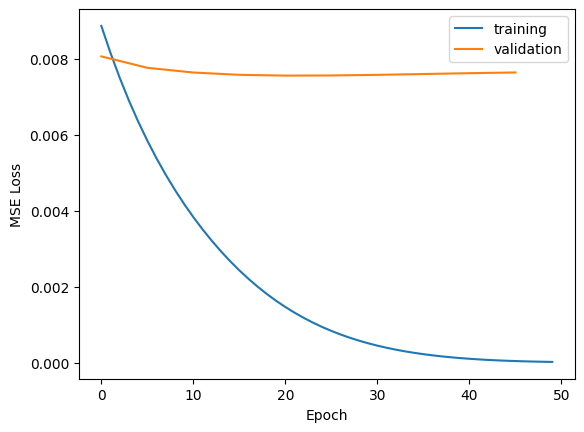

In [22]:
plt.plot(errors_train, label='training')
plt.plot([5*i for i in range(10)], errors_valid, label='validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1128665..3.6619654].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0867772..3.617968].


Text(0.5, 1.0, 'Reconstructed replay')

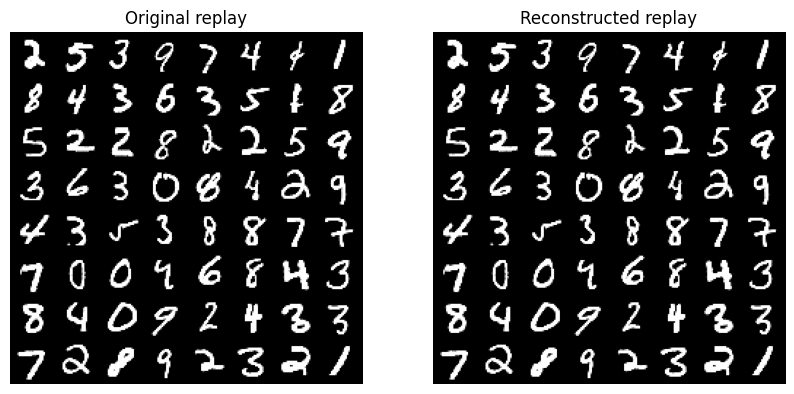

In [90]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
ca3_batch, ec_batch = next(iter(small_train_loader))
ec_batch = pcn.utils.set_tensor(ec_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[0], pcmodel.preds[-1], size)

ca3_batch = pcn.utils.set_tensor(ca3_batch)
ec_batch_hat = model(ca3_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch_hat, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[1], pcmodel.preds[-1], size)

axes[0].set_title('Original replay')
axes[1].set_title('Reconstructed replay')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0505767..3.7465405].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.731129..6.7708216].


Text(0.5, 1.0, 'Reconstructed replay')

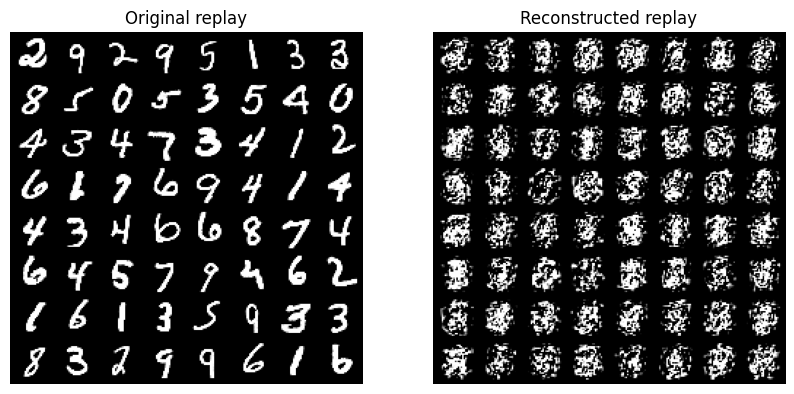

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
ca3_batch, ec_batch = next(iter(valid_loader))
ec_batch = pcn.utils.set_tensor(ec_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[0], pcmodel.preds[-1], size)

ca3_batch = pcn.utils.set_tensor(ca3_batch)
ec_batch_hat = model(ca3_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch_hat, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[1], pcmodel.preds[-1], size)

axes[0].set_title('Original replay')
axes[1].set_title('Reconstructed replay')

#### Early stopping

In [23]:
# Early stopping

model = nn.Sequential(
    nn.Linear(in_features=n_ca3, out_features=n_ca1),
    nn.Tanh(), 
    nn.Linear(in_features=n_ca1, out_features=n_ec),
    nn.Tanh()
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

errors_train, errors_valid = utils.train_model(model, small_train_loader, valid_loader, optimizer, criterion, device, lambda_reg=0, n_epochs=25)

Epoch [  5/ 25] finished. Training loss: 0.00622. Validation loss: 0.00804.
Epoch [ 10/ 25] finished. Training loss: 0.00408. Validation loss: 0.00778.
Epoch [ 15/ 25] finished. Training loss: 0.00260. Validation loss: 0.00766.
Epoch [ 20/ 25] finished. Training loss: 0.00158. Validation loss: 0.00761.
Epoch [ 25/ 25] finished. Training loss: 0.00090. Validation loss: 0.00759.


Text(0, 0.5, 'MSE Loss')

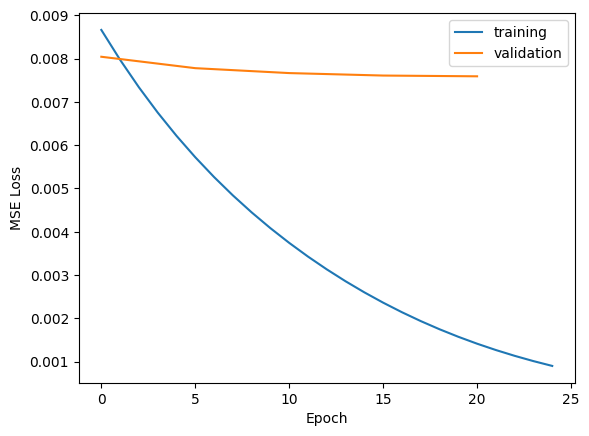

In [24]:
plt.plot(errors_train, label='training')
plt.plot([5*i for i in range(5)], errors_valid, label='validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

In [25]:
torch.save(model.state_dict(), f'models/mnist_batch_decoder.pt')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0152268..3.675299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9496932..4.234082].


Text(0.5, 1.0, 'Reconstructed replay')

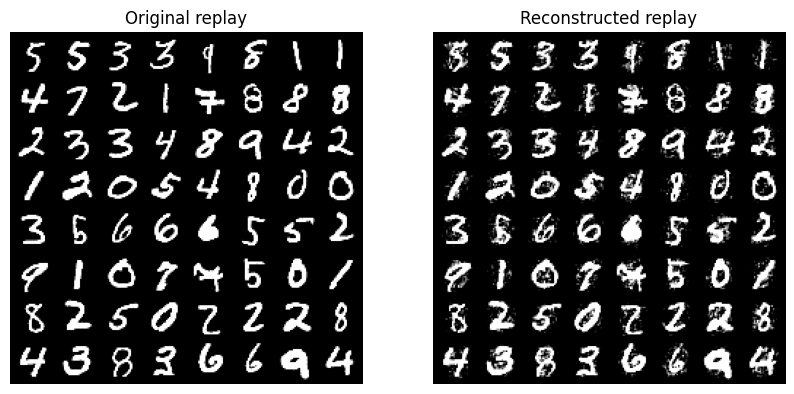

In [26]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
ca3_batch, ec_batch = next(iter(small_train_loader))
ec_batch = pcn.utils.set_tensor(ec_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[0], pcmodel.preds[-1], size)

ca3_batch = pcn.utils.set_tensor(ca3_batch)
ec_batch_hat = model(ca3_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch_hat, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[1], pcmodel.preds[-1], size)

axes[0].set_title('Original replay')
axes[1].set_title('Reconstructed replay')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1993951..3.7692666].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.1399803..6.189473].


Text(0.5, 1.0, 'Reconstructed replay')

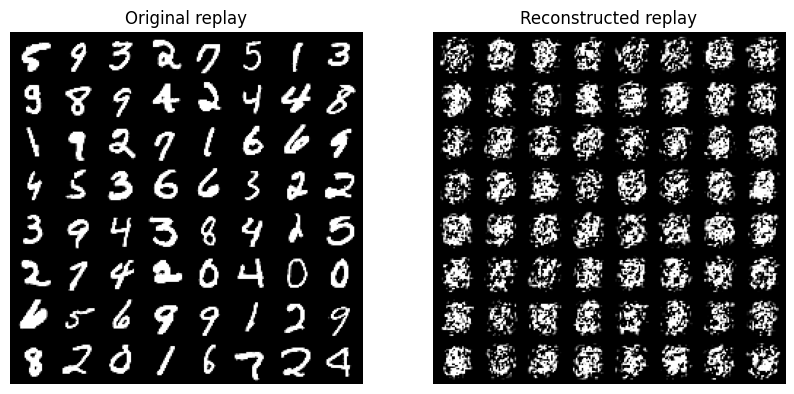

In [27]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
ca3_batch, ec_batch = next(iter(valid_loader))
ec_batch = pcn.utils.set_tensor(ec_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[0], pcmodel.preds[-1], size)

ca3_batch = pcn.utils.set_tensor(ca3_batch)
ec_batch_hat = model(ca3_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch_hat, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[1], pcmodel.preds[-1], size)

axes[0].set_title('Original replay')
axes[1].set_title('Reconstructed replay')

### Whole training set

In [28]:
device = pcn.utils.DEVICE

model = nn.Sequential(
    nn.Linear(in_features=n_ca3, out_features=n_ca1),
    nn.Tanh(), 
    nn.Linear(in_features=n_ca1, out_features=n_ec),
    nn.Tanh()
).to(device)

criterion = nn.MSELoss()
lr = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [29]:
errors_train, errors_valid = utils.train_model(model, train_loader, valid_loader, optimizer, criterion, device, lambda_reg=0)

Epoch [  5/ 50] finished. Training loss: 0.00194. Validation loss: 0.00196.
Epoch [ 10/ 50] finished. Training loss: 0.00194. Validation loss: 0.00195.
Epoch [ 15/ 50] finished. Training loss: 0.00193. Validation loss: 0.00195.
Epoch [ 20/ 50] finished. Training loss: 0.00193. Validation loss: 0.00194.
Epoch [ 25/ 50] finished. Training loss: 0.00192. Validation loss: 0.00194.
Epoch [ 30/ 50] finished. Training loss: 0.00192. Validation loss: 0.00194.
Epoch [ 35/ 50] finished. Training loss: 0.00191. Validation loss: 0.00193.
Epoch [ 40/ 50] finished. Training loss: 0.00191. Validation loss: 0.00193.
Epoch [ 45/ 50] finished. Training loss: 0.00190. Validation loss: 0.00193.
Epoch [ 50/ 50] finished. Training loss: 0.00190. Validation loss: 0.00193.


In [55]:
torch.save(model.state_dict(), f'models/mnist_decoder.pt')

In [ ]:
len(errors_train)

50

Text(0, 0.5, 'MSE Loss')

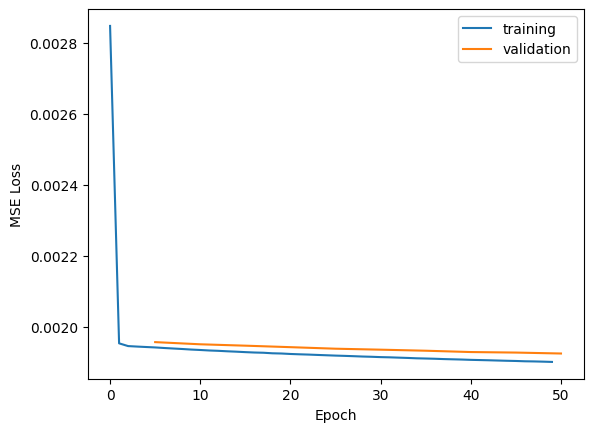

In [33]:
plt.plot(errors_train, label='training')
plt.plot([5*(i+1) for i in range(10)], errors_valid, label='validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

In [13]:
# dataset params
train_size = None
test_size = None
normalize = True
batch_size = 64

# inference params
mu_dt = 0.01
n_test_iters = 200
n_max_iters = 20000
step_tolerance = 1e-5
init_std = 0.01
fixed_preds_test = False

# model params
use_bias = True
kaiming_init = False
n_ec = 300
act_fn = "tanh"
kaiming = False

In [14]:
if dataset_name == 'mnist':
    n_vc = 550
elif dataset_name  == 'fmnist':
    n_vc = 750
else:
    n_vc = 2000

nodes = [n_ec, n_vc, np.prod(size)]
    
model_name = f"pcn-{dataset_name}-n_vc={n_vc}-n_ec={n_ec}" 
pcmodel = PCModel(
    nodes=nodes, mu_dt=mu_dt, act_fn=act_fn, use_bias=use_bias, kaiming_init=kaiming_init
)
pcmodel.load_state_dict(torch.load(f"../unsupervised-pcn/models/{model_name}.pt", map_location=pcn.utils.DEVICE, weights_only=True))

<All keys matched successfully>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0073696..3.5464444].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8224983..3.6300342].


Text(0.5, 1.0, 'Reconstructed replay')

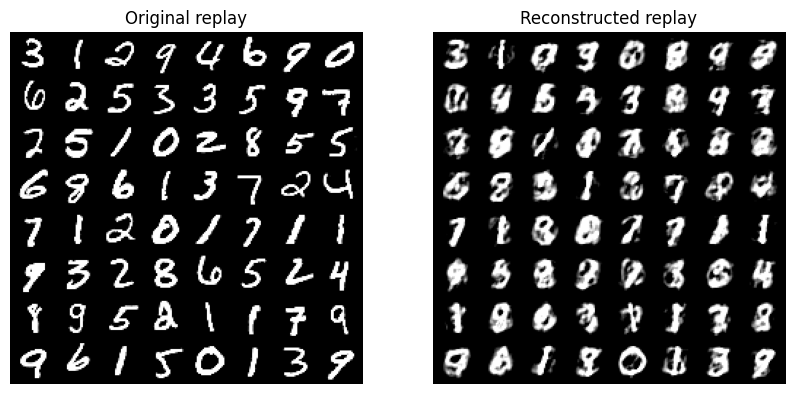

In [15]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
ca3_batch, ec_batch = next(iter(train_loader))
ec_batch = pcn.utils.set_tensor(ec_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[0], pcmodel.preds[-1], size)

ca3_batch = pcn.utils.set_tensor(ca3_batch)
ec_batch_hat = model(ca3_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch_hat, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[1], pcmodel.preds[-1], size)

axes[0].set_title('Original replay')
axes[1].set_title('Reconstructed replay')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1535965..3.6557097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4017789..3.7427547].


Text(0.5, 1.0, 'Reconstructed replay')

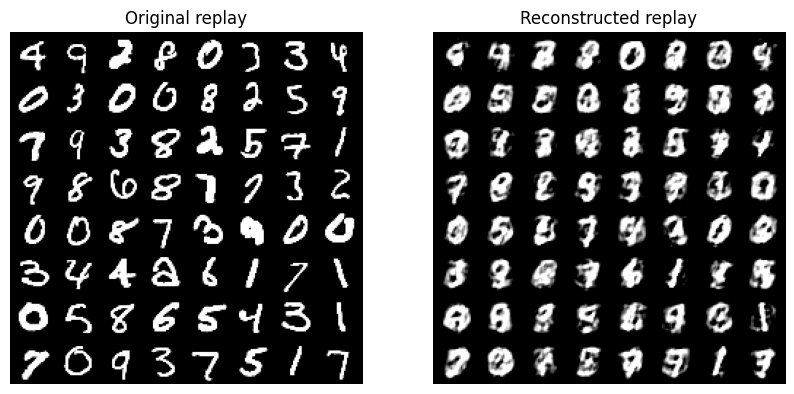

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
ca3_batch, ec_batch = next(iter(valid_loader))
ec_batch = pcn.utils.set_tensor(ec_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[0], pcmodel.preds[-1], size)

ca3_batch = pcn.utils.set_tensor(ca3_batch)
ec_batch_hat = model(ca3_batch)

with torch.no_grad():
    pcmodel.replay_batch(
        ec_batch_hat, 
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
plotting.plot_samples(axes[1], pcmodel.preds[-1], size)

axes[0].set_title('Original replay')
axes[1].set_title('Reconstructed replay')

## Visualization

In [ ]:
model = nn.Sequential(
    nn.Linear(in_features=n_ca3, out_features=n_ca1),
    nn.Tanh(), 
    nn.Linear(in_features=n_ca1, out_features=n_ec),
    nn.Tanh()
).to(device)

### Small dataset

In [ ]:
model.load_state_dict(torch.load(f'models/mnist_batch_decoder.pt', map_location=pcn.utils.DEVICE))

In [ ]:
activities = [ca3_train, ca1_train, ec_train]

### Whole dataset

In [ ]:
model.load_state_dict(torch.load(f'models/mnist_decoder.pt', map_location=pcn.utils.DEVICE))

## Sampling

In [ ]:
model = nn.Sequential(
    nn.Linear(in_features=n_ca3, out_features=n_ca1),
    nn.Tanh(), 
    nn.Linear(in_features=n_ca1, out_features=n_ec),
    nn.Tanh()
).to(device)

### Small dataset

In [ ]:
model.load_state_dict(torch.load(f'models/mnist_batch_decoder.pt', map_location=pcn.utils.DEVICE))

#### CA3

In [74]:
with torch.no_grad():
    h_train = torch.matmul(dg_train, DG_CA3.weights)

(array([1.2000000e+01, 3.0900000e+02, 1.4388000e+04, 5.6722000e+05,
        9.8038160e+06, 2.0286403e+07, 3.2981960e+06, 1.1601000e+05,
        2.6590000e+03, 7.5000000e+01]),
 array([-0.0773976 , -0.06273597, -0.04807434, -0.03341271, -0.01875108,
        -0.00408944,  0.01057218,  0.02523381,  0.03989545,  0.05455707,
         0.06921872]),
 <BarContainer object of 10 artists>)

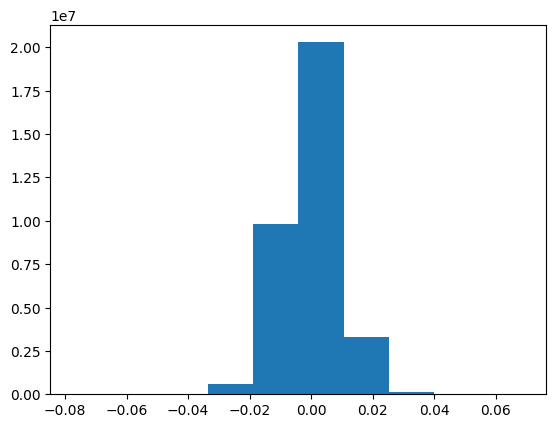

In [31]:
plt.hist(h_train.flatten())

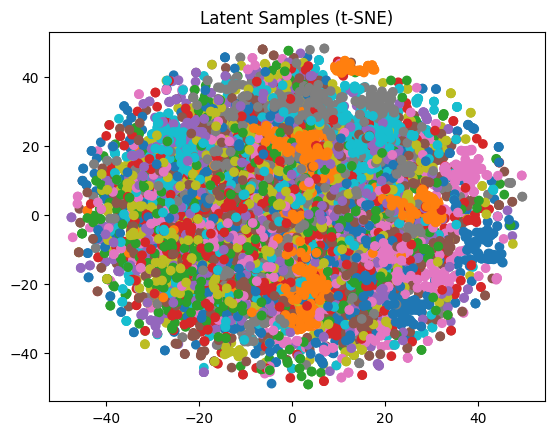

In [64]:
fig, ax = plt.subplots()
N_valid = len(ec_valid)
plotting.visualize_latent(ax, h_train[:N_valid], labels_train[:N_valid])

In [75]:
classes = np.unique(labels_train)
labels = []
ec_batch_euclid = []
ec_stat = {'mu': [], 'cov': []}
with torch.no_grad():
    for i in classes:
        indices = np.where(labels_train == i)[0]
        h_class = np.array(h_train)[indices]
        h_sample = pcn.utils.sample_from_latent(h_class, batch_size).float()
        ca3 = DG_CA3.apply_inhibition(h_sample)
        ca3 = ca3.to(device)
        ec = model(ca3).cpu()
        ec_batch_euclid.append(ec)
        labels += [i for _ in range(batch_size)]

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_46484\1796065167.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  h_class = np.array(h_train)[indices]


(array([  13.,  175.,  980., 3261., 5816., 5308., 2804.,  716.,  119.,
           8.]),
 array([-0.29590115, -0.23519616, -0.17449117, -0.11378616, -0.05308117,
         0.00762382,  0.06832883,  0.1290338 ,  0.18973881,  0.25044379,
         0.31114882]),
 <BarContainer object of 10 artists>)

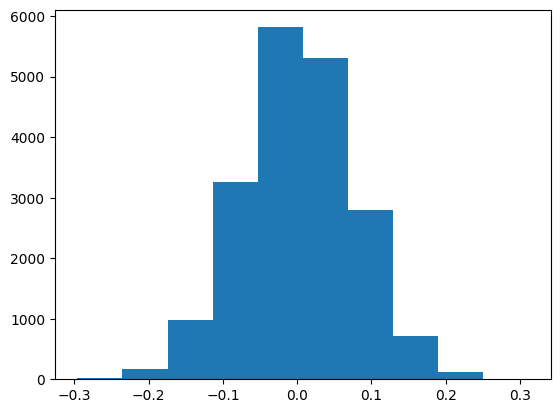

In [33]:
plt.hist(ec.flatten())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.7426615..6.25273].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.9932857..6.2463555].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.856066..6.2322187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.2012534..7.2688913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.4991026..6.539631].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.6237173..6.448513].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.935007..6.1

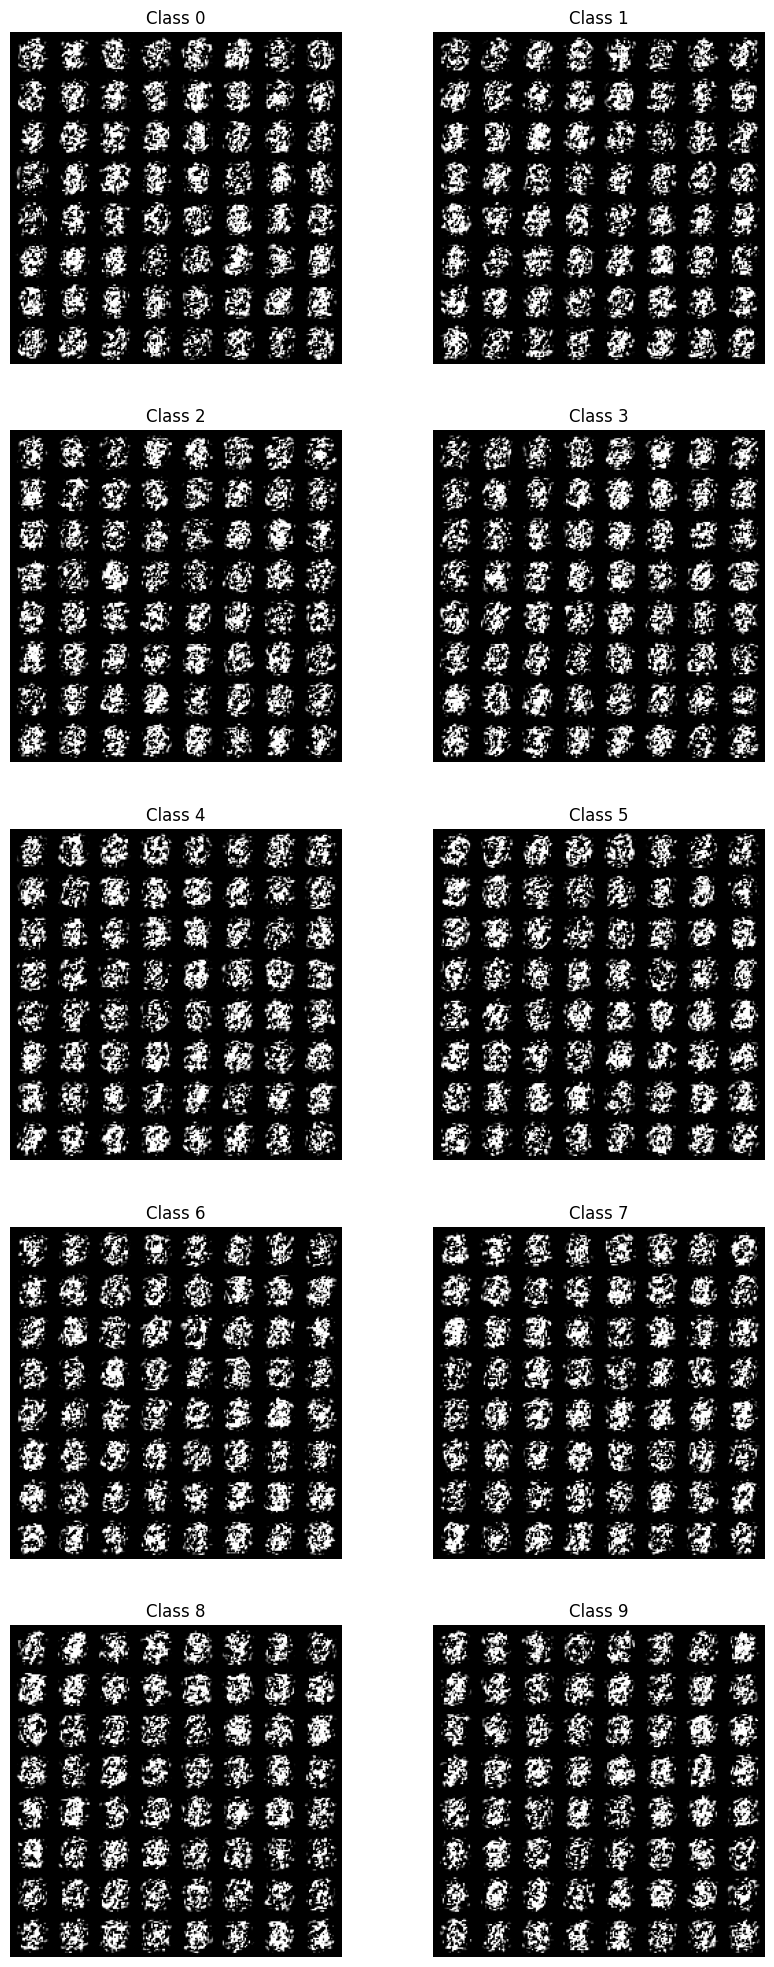

In [77]:
K = len(classes)
nrows = K//2
ncols = 2
fig1, axes = plt.subplots(nrows, ncols, figsize = (5*ncols, 5*nrows))

for k in range(K):
    label = int(labels[k*batch_size])
    batch = pcn.utils.set_tensor(ec_batch_euclid[k])
    with torch.no_grad():
        pcmodel.replay_batch(
            batch,
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )    
    i = k//2
    j = k%2
    axes[i, j].set_title(f'Class {label}')
    pcn.plotting.plot_samples(axes[i, j], pcmodel.preds[-1], size)

#### CA1

In [40]:
ca3_train.shape

torch.Size([49984, 682])

In [78]:
with torch.no_grad():
    ca3_train = ca3_train.to(device)
    ca1_train = model[:2](ca3_train)

(array([8.7900000e+02, 8.4917000e+04, 1.4178810e+06, 7.5500930e+06,
        1.6722139e+07, 1.7258326e+07, 8.3370130e+06, 1.6968760e+06,
        1.1341400e+05, 1.4380000e+03]),
 array([-0.6462661 , -0.51833665, -0.39040715, -0.26247767, -0.13454819,
        -0.00661874,  0.12131077,  0.24924028,  0.37716973,  0.50509918,
         0.63302863]),
 <BarContainer object of 10 artists>)

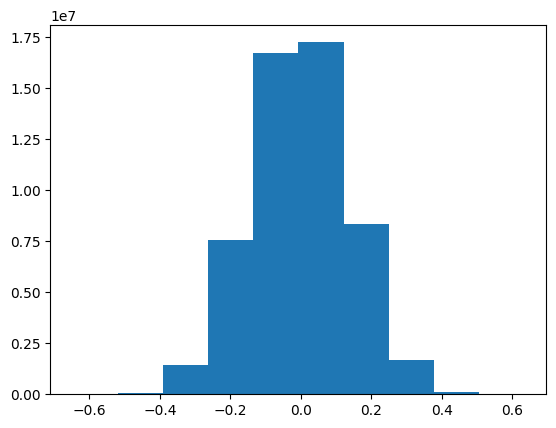

In [80]:
ca1_train = ca1_train.cpu()
plt.hist(ca1_train.flatten())

In [81]:
classes = np.unique(labels_train)
labels = []
ec_batch_euclid = []
ec_stat = {'mu': [], 'cov': []}
with torch.no_grad():
    for i in classes:
        indices = np.where(labels_train == i)[0]
        ca1_class = np.array(ca1_train)[indices]
        ca1_sample = pcn.utils.sample_from_latent(ca1_class, batch_size).float()
        ca1_sample = ca1_sample.to(device)
        ec = model[2:](ca1_sample).cpu()
        ec_batch_euclid.append(ec)
        labels += [i for _ in range(batch_size)]

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_46484\2122233209.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ca1_class = np.array(ca1_train)[indices]


(array([  11.,  187., 1038., 3272., 5434., 5235., 2961.,  892.,  154.,
          16.]),
 array([-0.28243321, -0.22507805, -0.16772288, -0.11036772, -0.05301255,
         0.00434262,  0.06169778,  0.11905295,  0.17640811,  0.23376328,
         0.29111841]),
 <BarContainer object of 10 artists>)

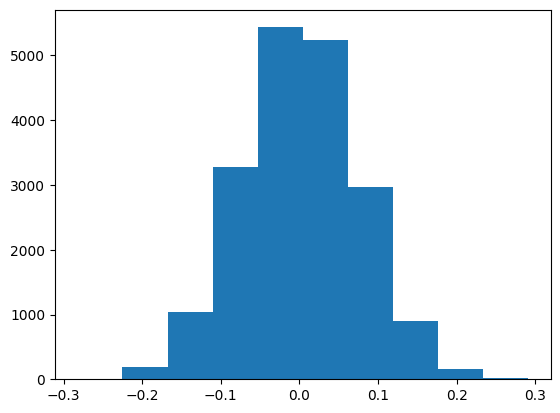

In [50]:
plt.hist(ec.flatten())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.3301015..6.1481295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.755897..6.098378].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.4257555..6.1312075].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.639969..5.716134].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1946373..6.0353994].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.4788017..5.809719].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0673294..6.

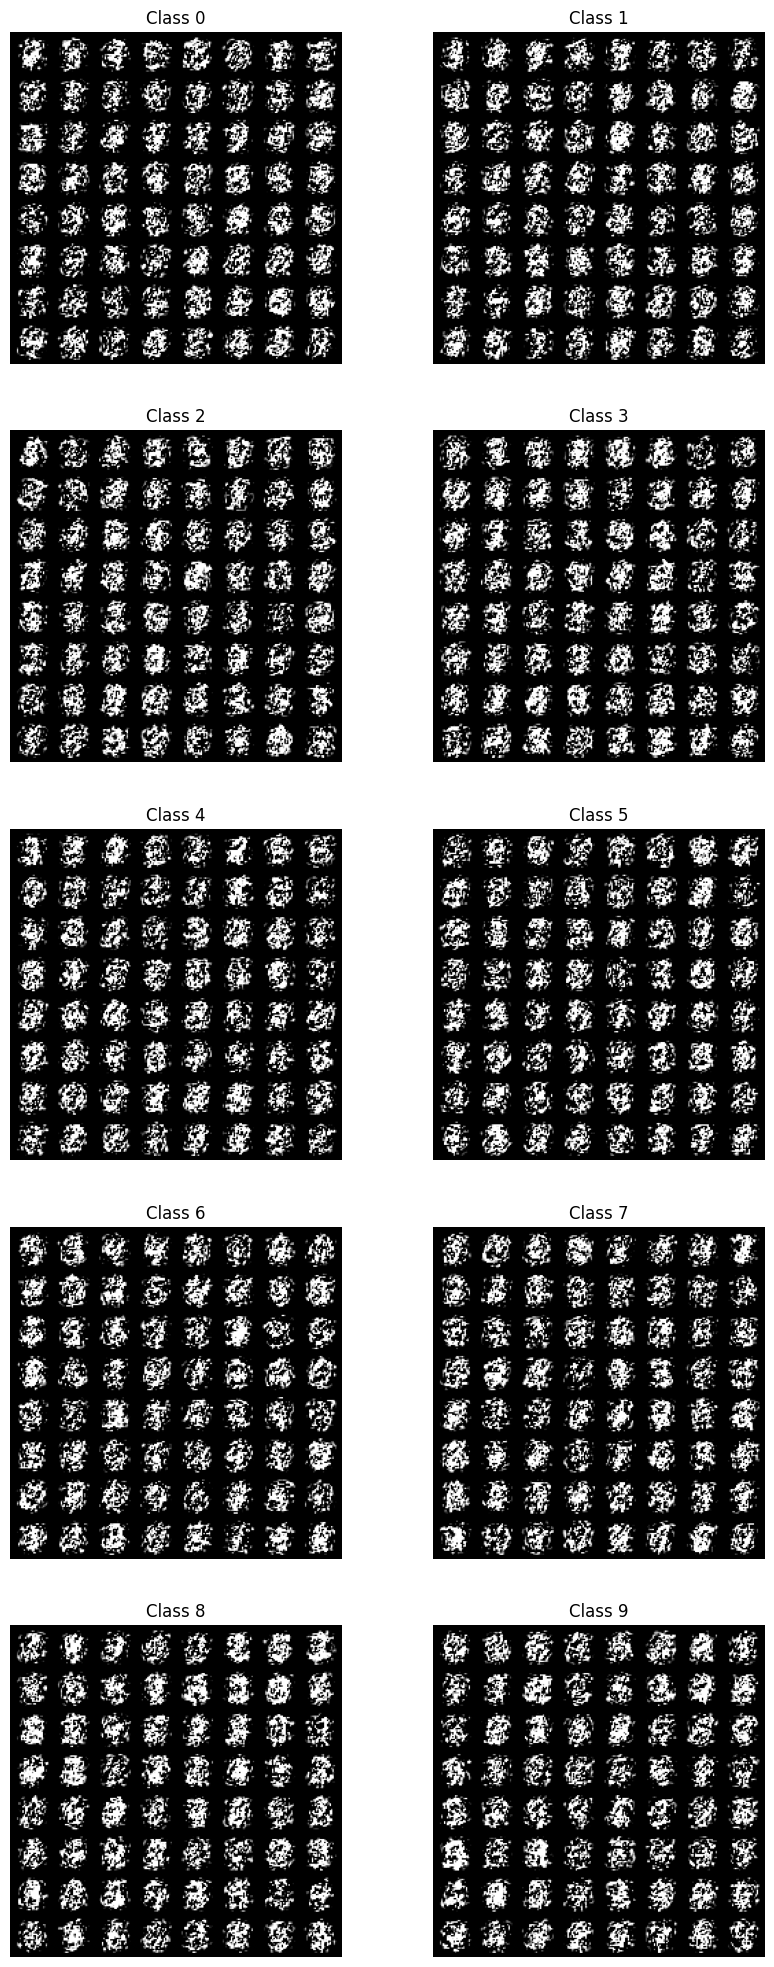

In [82]:
K = len(classes)
nrows = K//2
ncols = 2
fig1, axes = plt.subplots(nrows, ncols, figsize = (5*ncols, 5*nrows))

for k in range(K):
    label = int(labels[k*batch_size])
    batch = pcn.utils.set_tensor(ec_batch_euclid[k])
    with torch.no_grad():
        pcmodel.replay_batch(
            batch,
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )    
    i = k//2
    j = k%2
    axes[i, j].set_title(f'Class {label}')
    pcn.plotting.plot_samples(axes[i, j], pcmodel.preds[-1], size)

### Whole dataset

In [ ]:
model.load_state_dict(torch.load(f'models/mnist_decoder.pt', map_location=pcn.utils.DEVICE))

#### CA3

In [58]:
with torch.no_grad():
    h_train = torch.matmul(dg_train, DG_CA3.weights)

(array([1.2000000e+01, 3.0900000e+02, 1.4388000e+04, 5.6722000e+05,
        9.8038160e+06, 2.0286403e+07, 3.2981960e+06, 1.1601000e+05,
        2.6590000e+03, 7.5000000e+01]),
 array([-0.0773976 , -0.06273597, -0.04807434, -0.03341271, -0.01875108,
        -0.00408944,  0.01057218,  0.02523381,  0.03989545,  0.05455707,
         0.06921872]),
 <BarContainer object of 10 artists>)

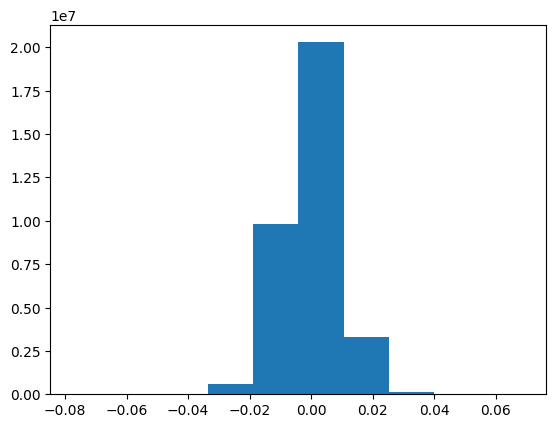

In [59]:
plt.hist(h_train.flatten())

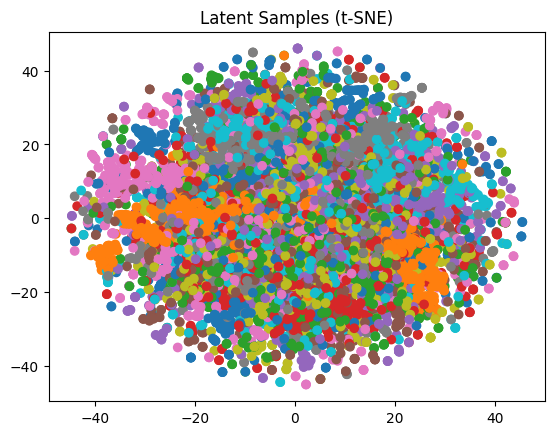

In [60]:
fig, ax = plt.subplots()
N_valid = len(ec_valid)
plotting.visualize_latent(ax, h_train[:N_valid], labels_train[:N_valid])

In [61]:
classes = np.unique(labels_train)
labels = []
ec_batch_euclid = []
ec_stat = {'mu': [], 'cov': []}
with torch.no_grad():
    for i in classes:
        indices = np.where(labels_train == i)[0]
        h_class = np.array(h_train)[indices]
        h_sample = pcn.utils.sample_from_latent(h_class, batch_size).float()
        ca3 = DG_CA3.apply_inhibition(h_sample)
        ca3 = ca3.to(device)
        ec = model(ca3).cpu()
        ec_batch_euclid.append(ec)
        labels += [i for _ in range(batch_size)]

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_46484\1796065167.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  h_class = np.array(h_train)[indices]


(array([9.000e+00, 1.060e+02, 1.000e+03, 4.040e+03, 7.201e+03, 5.088e+03,
        1.557e+03, 1.820e+02, 1.600e+01, 1.000e+00]),
 array([-0.07870822, -0.06168192, -0.04465562, -0.02762933, -0.01060303,
         0.00642326,  0.02344956,  0.04047585,  0.05750215,  0.07452844,
         0.09155475]),
 <BarContainer object of 10 artists>)

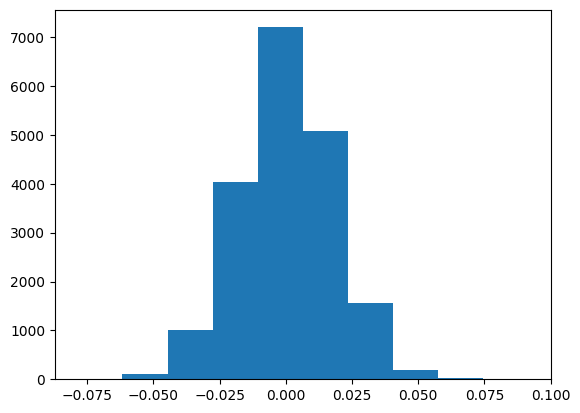

In [62]:
plt.hist(ec.flatten())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8745226..3.4624767].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.852447..3.7835634].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.533705..3.3109927].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.335789..2.9701743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4464955..3.1625018].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6697744..3.1583848].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3715465..

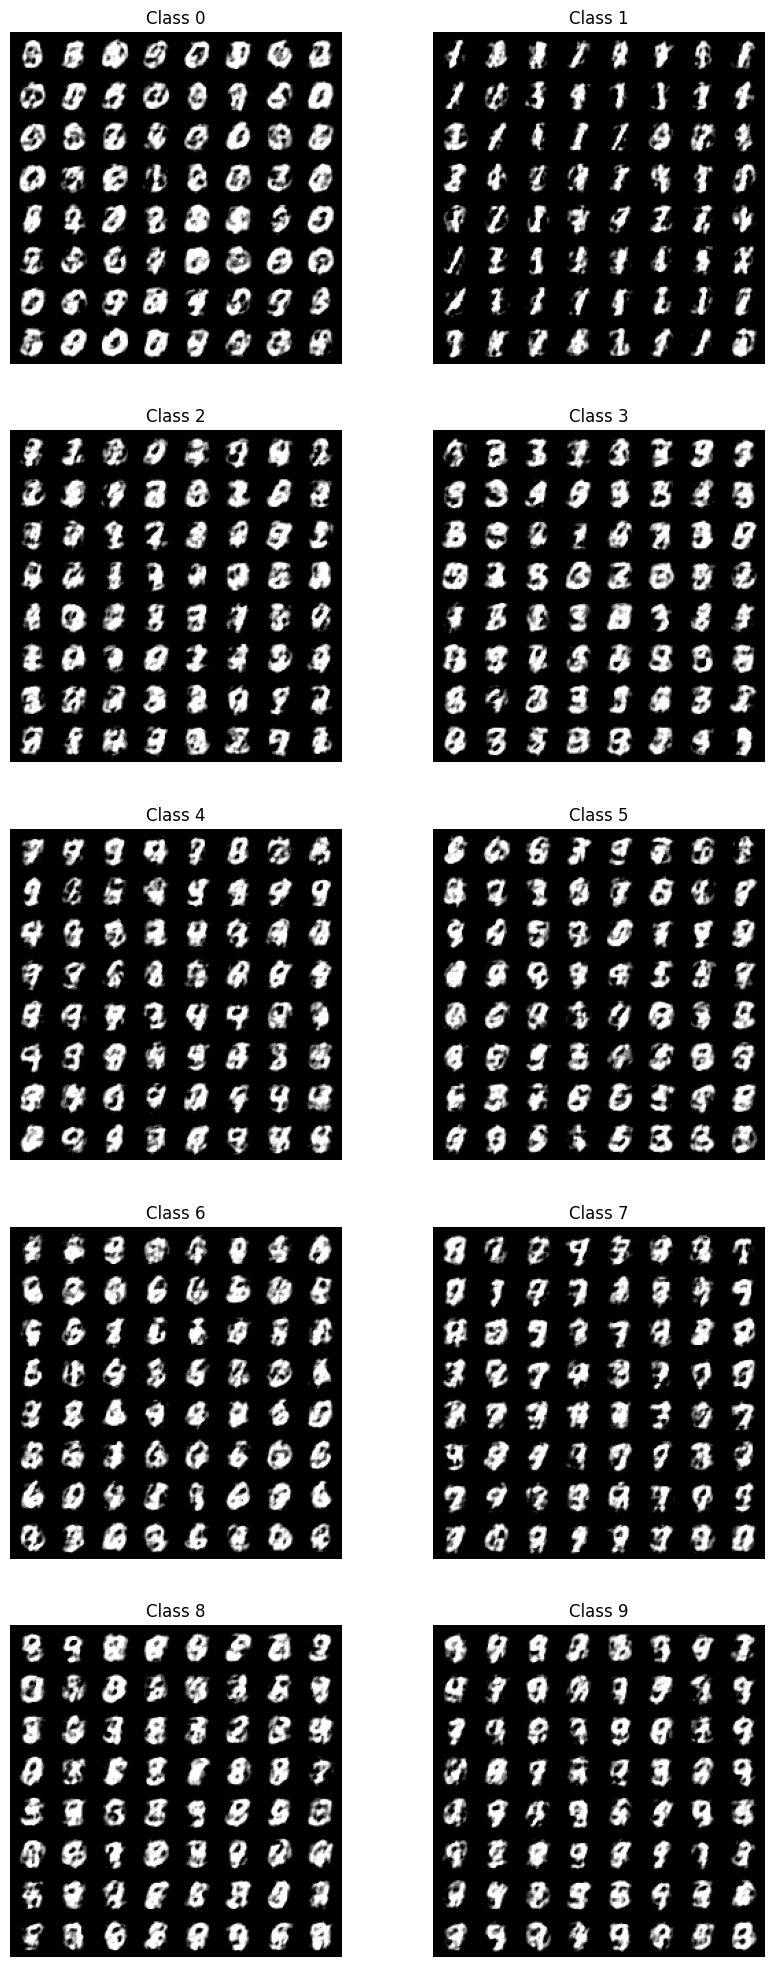

In [63]:
K = len(classes)
nrows = K//2
ncols = 2
fig1, axes = plt.subplots(nrows, ncols, figsize = (5*ncols, 5*nrows))

for k in range(K):
    label = int(labels[k*batch_size])
    batch = pcn.utils.set_tensor(ec_batch_euclid[k])
    with torch.no_grad():
        pcmodel.replay_batch(
            batch,
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )    
    i = k//2
    j = k%2
    axes[i, j].set_title(f'Class {label}')
    pcn.plotting.plot_samples(axes[i, j], pcmodel.preds[-1], size)

#### CA1

In [64]:
with torch.no_grad():
    ca3_train = ca3_train.to(device)
    ca1_train = model[:2](ca3_train)

(array([1.9800000e+02, 1.4165000e+04, 4.6530800e+05, 5.6237770e+06,
        2.0819602e+07, 2.0454202e+07, 5.3563180e+06, 4.3569100e+05,
        1.3522000e+04, 1.9300000e+02]),
 array([-0.41875109, -0.33478719, -0.25082326, -0.16685936, -0.08289543,
         0.0010685 ,  0.08503237,  0.1689963 ,  0.25296023,  0.33692417,
         0.4208881 ]),
 <BarContainer object of 10 artists>)

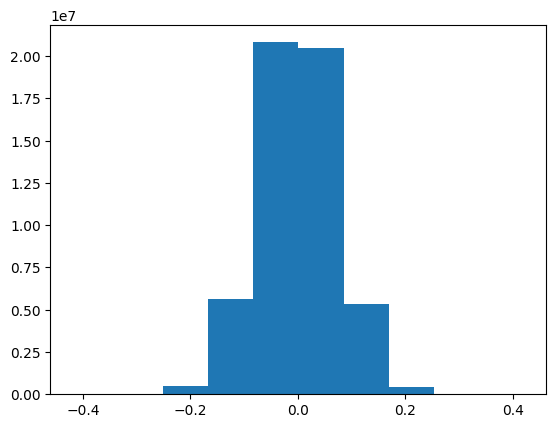

In [65]:
ca1_train = ca1_train.cpu()
plt.hist(ca1_train.flatten())

In [66]:
classes = np.unique(labels_train)
labels = []
ec_batch_euclid = []
ec_stat = {'mu': [], 'cov': []}
with torch.no_grad():
    for i in classes:
        indices = np.where(labels_train == i)[0]
        ca1_class = np.array(ca1_train)[indices]
        ca1_sample = pcn.utils.sample_from_latent(ca1_class, batch_size).float()
        ca1_sample = ca1_sample.to(device)
        ec = model[2:](ca1_sample).cpu()
        ec_batch_euclid.append(ec)
        labels += [i for _ in range(batch_size)]

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_46484\2122233209.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ca1_class = np.array(ca1_train)[indices]


(array([2.000e+00, 4.200e+01, 3.540e+02, 1.766e+03, 4.777e+03, 6.380e+03,
        4.158e+03, 1.412e+03, 2.710e+02, 3.800e+01]),
 array([-0.0843668 , -0.06881379, -0.05326077, -0.03770775, -0.02215474,
        -0.00660172,  0.00895129,  0.02450431,  0.04005732,  0.05561034,
         0.07116336]),
 <BarContainer object of 10 artists>)

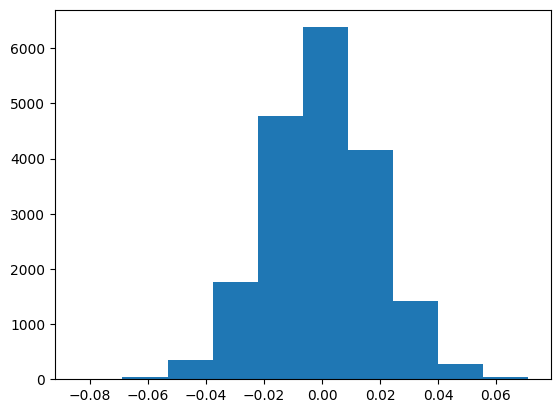

In [67]:
plt.hist(ec.flatten())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5125687..3.4850264].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.303567..4.289218].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.385309..3.003768].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3817786..3.0083287].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6289818..3.1528473].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4323149..3.1600783].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8753599..3

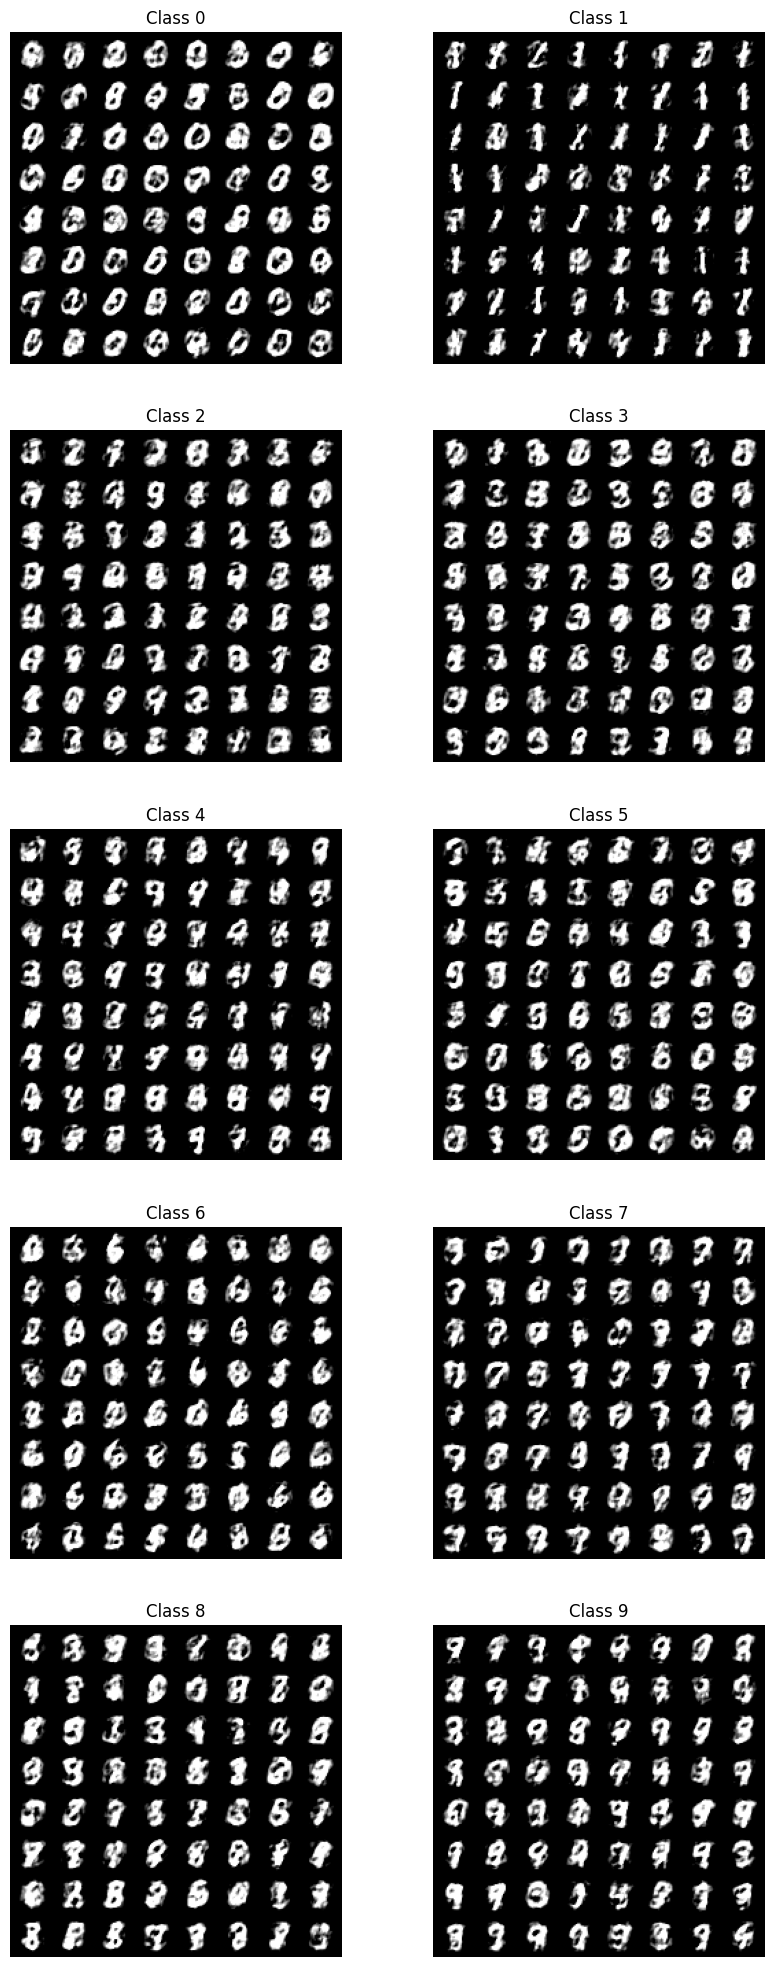

In [68]:
K = len(classes)
nrows = K//2
ncols = 2
fig1, axes = plt.subplots(nrows, ncols, figsize = (5*ncols, 5*nrows))

for k in range(K):
    label = int(labels[k*batch_size])
    batch = pcn.utils.set_tensor(ec_batch_euclid[k])
    with torch.no_grad():
        pcmodel.replay_batch(
            batch,
            n_max_iters,
            step_tolerance=step_tolerance,
            init_std=init_std,
            fixed_preds=fixed_preds_test
        )    
    i = k//2
    j = k%2
    axes[i, j].set_title(f'Class {label}')
    pcn.plotting.plot_samples(axes[i, j], pcmodel.preds[-1], size)